### Data Selection for Finetuning Ag slab w/ [C, H, O] adsorbates

Download OUTCAR for each pre-screened folder listed in cache/<origin_dataset-folder>/selected_foldernames.txt

In [11]:
import os
import time
import glob
import re
from dotenv import load_dotenv

load_dotenv(override=True)

# USER INPUT HERE: set cache folder for the dataset being selected from
CACHE = "cache/box_EO_Project_reactivity/"

In [5]:
# read in raw folder names list from cache
with open(f"{CACHE}/selected_foldernames.txt", "r", encoding="utf-8") as f:
    foldernames = [line.strip() for line in f]

print(f"Total items: {len(foldernames)}")

Total items: 187


In [6]:
# get all numeric suffixes N among files named '{prefix}-N' in names
def all_suffixes(names, prefix):
      # params:  names  - iterable[str], filenames from a folder listing
      #          prefix - str, base filename to match (e.g. "OUTCAR")
      # return:  list[int] - all N found (empty list if none)
      return [int(m.group(1)) for n in names
            if (m := re.fullmatch(rf"{prefix}-(\d+)", n))]


# get highest numeric suffix N among files named '{prefix}-N' in names
def max_suffix(names, prefix):
      # names: filenames from a folder listing; prefix: base name (e.g. "OUTCAR")
      # returns: max N found, or None if no numbered files exist
      # NOTE: this is the second-to-latest file in timeseries order — '{prefix}' with no suffix is latest
      ns = (int(m.group(1)) for n in names
            if (m := re.fullmatch(rf"{prefix}-(\d+)", n)))
      return max(ns, default=None)

### for DropBox

In [ ]:
import dropbox
from dropbox.files import SharedLink

DB_TOKEN = os.getenv("DROPBOX_TOKEN")
ROOT_PATH = SharedLink(url="https://www.dropbox.com/scl/fo/qpg1zuo3g7vb3il1wmqy3/AA4wERzz28lJhYTCAcSEvqk?dl=0")

dbx = dropbox.Dropbox(DB_TOKEN, timeout=900)

In [ ]:
# download files from DropBox

# set to `False` to skip writing already-existing files
OVERWRITE = False

# skips writing already-existing files:
def download_file(folder, fname, outdir):
    out_path = f"{outdir}/{folder}_{fname}"
    if not OVERWRITE and os.path.exists(out_path):
        return
        
    _, res = dbx.sharing_get_shared_link_file(url=ROOT_PATH.url, path=f"/{folder}/{fname}")
    with open(out_path, "wb") as f:
        f.write(res.content)

In [ ]:
# call DropBox API here to download OUTCARs and INCARs

no_outcars, no_incars, failed_folders = [], [], {}

for folder in foldernames:
    folder_path = f"/{folder}"
    try:
        res = dbx.files_list_folder(path=folder_path, shared_link=ROOT_PATH)
        names = {e.name for e in res.entries}
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"ERROR: folder listing failed -> {folder}: {e}")
        continue
    
    # download all OUTCARs in DFT run folder
    if "OUTCAR" not in names:
        no_outcars.append(folder)
        print(f"MISSING: no OUTCAR in -> {folder}")
    else:
        try:
            download_file(folder, "OUTCAR", "outcars")
            for n in all_suffixes(names, "OUTCAR"):
                download_file(folder, f"OUTCAR-{n}", "outcars")
        except dropbox.exceptions.ApiError as e:
            failed_folders[folder] = str(e)
            print(f"ERROR: OUTCAR download failed -> {folder}: {e}")
    
    # download latest INCAR in each folder
    if "INCAR" not in names:
        no_incars.append(folder)
        print(f"MISSING: no INCAR in -> {folder}")
    else:
        try:
            download_file(folder, "INCAR", "incars")
        except dropbox.exceptions.ApiError as e:
            no_incars.append(folder)
            print(f"ERROR: INCAR download failed -> {folder}: {e}")

    time.sleep(0.2)

print(f"No OUTCAR: {len(no_outcars)} | No/failed INCAR: {len(no_incars)} | Failed folder listings: {len(failed_folders)}")

No OUTCAR: 0 | No/failed INCAR: 0 | Failed folder listings: 0


### for Box

In [7]:
from box_sdk_gen import BoxClient, BoxDeveloperTokenAuth
load_dotenv(override=True)

BOX_DEV_TOKEN = os.getenv("DEVELOPER_TOKEN")
BOX_FOLDER_IDS = ["376580648972", "376581493469"]
# EO_Project_reactivity, EO_Project_reactivity_part2

auth = BoxDeveloperTokenAuth(BOX_DEV_TOKEN)
client = BoxClient(auth)

In [8]:
# get all folder names+ids via Box API and store in set

subfolder_map = {}   # name -> folder_id
for folder_id in BOX_FOLDER_IDS:
    offset = 0
    limit = 1000
    while True:
        items = client.folders.get_folder_items(folder_id, limit=limit, offset=offset)
        for item in items.entries:
            if item.type == "folder":
                subfolder_map[item.name] = item.id
        offset += len(items.entries)
        if offset >= items.total_count:
            break

# filter out folders not cached in selected_foldernames.txt
with open(f"{CACHE}/selected_foldernames.txt", "r", encoding="utf-8") as f:
    selected = {line.strip() for line in f if line.strip()}

subfolder_map = {k: v for k, v in subfolder_map.items() if k in selected}

In [9]:
# download files from Box
from box_sdk_gen import BoxAPIError

# set to `False` to skip writing already-existing files
OVERWRITE = False

def download_file(folder, fname, file_id, outdir):
    out_path = f"{outdir}/{folder}_{fname}"
    if (not OVERWRITE) and os.path.exists(out_path):
        return
    stream = client.downloads.download_file(file_id)
    with open(out_path, "wb") as f:
        f.write(stream.read())

no_outcars, no_incars, failed_folders = [], [], {}

for folder, folder_id in subfolder_map.items():
    try:
        items = client.folders.get_folder_items(folder_id, limit=1000)
        names = {e.name: e.id for e in items.entries}
    except BoxAPIError as e:
        failed_folders[folder] = str(e)
        print(f"ERROR: folder listing failed -> {folder}: {e}")
        continue

    # OUTCARs
    if "OUTCAR" not in names:
        no_outcars.append(folder)
        print(f"MISSING: no OUTCAR in -> {folder}")
    else:
        try:
            download_file(folder, "OUTCAR", names["OUTCAR"], "outcars")
            for n in all_suffixes(names.keys(), "OUTCAR"):
                suffix_name = f"OUTCAR-{n}"
                download_file(folder, suffix_name, names[suffix_name], "outcars")
        except BoxAPIError as e:
            failed_folders[folder] = str(e)
            print(f"ERROR: OUTCAR download failed -> {folder}: {e}")

    # get latest INCAR
    if "INCAR" not in names:
        no_incars.append(folder)
        print(f"MISSING: no INCAR in -> {folder}")
    else:
        try:
            download_file(folder, "INCAR", names["INCAR"], "incars")
        except BoxAPIError as e:
            no_incars.append(folder)
            print(f"ERROR: INCAR download failed -> {folder}: {e}")

    time.sleep(0.2)

print(f"No OUTCAR: {len(no_outcars)} | No/failed INCAR: {len(no_incars)} | Failed folder listings: {len(failed_folders)}")

No OUTCAR: 0 | No/failed INCAR: 0 | Failed folder listings: 0


Get energy trajectories of each run to plot and check for convergence

In [10]:
# gets "Free energy (TOTEN)" at each ionic step in an OUTCAR file.

def get_energies(outcar_path):
    energies = []
    with open(outcar_path, "r", errors="ignore") as f:
        for line in f:
            if "free  energy   TOTEN" in line:
                energies.append(float(line.split()[-2]))
    return energies

def get_all_energies_with_bounds(folder, outcar_dir="outcars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    energies, bounds = [], []
    if max_n is not None:
        for i in range(1, max_n + 1):
            energies += get_energies(f"{outcar_dir}/{folder}_OUTCAR-{i}")
            bounds.append(len(energies))
    base_path = f"{outcar_dir}/{folder}_OUTCAR"
    if os.path.exists(base_path):
        energies += get_energies(base_path)
    return energies, bounds

Remove uncoverged runs where the # of ionic steps taken in the last OUTCAR = NSW (max step limit)

In [12]:
# get max OUTCAR suffix per folder (from already-downloaded files)
def build_suffix_map(foldernames, outdir="outcars"):
    # returns:  dict[str, int|None] - folder -> max OUTCAR-N suffix (None if base only)

    suffix_map = {}
    for folder in foldernames:
        names = {os.path.basename(p)[len(folder) + 1:]
                for p in glob.glob(f"{outdir}/{folder}_OUTCAR*")}
        suffix_map[folder] = max_suffix(names, "OUTCAR")
    return suffix_map

In [13]:
suffix_map = build_suffix_map(foldernames)

In [14]:
def get_nsw(folder, incar_dir="incars"):
    with open(f"{incar_dir}/{folder}_INCAR", "r", errors="ignore") as f:
        for line in f:
            if line.strip().upper().startswith("NSW"):
                return int(line.split("=")[1].split()[0])
    return None

In [15]:
# compare ionic steps taken in last OUTCAR segment to NSW for a folder

def compare_to_nsw(folder, outcar_dir="outcars", incar_dir="incars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    base_path = f"{outcar_dir}/{folder}_OUTCAR"
    if os.path.exists(base_path):
        outcar_name = "OUTCAR"
    else:
        outcar_name = f"OUTCAR-{max_n}"
    actual = len(get_energies(f"{outcar_dir}/{folder}_{outcar_name}"))
    nsw = get_nsw(folder, incar_dir)
    return {"actual": actual, "nsw": nsw, "hit_limit": nsw is not None and actual >= nsw}

In [17]:
compare_to_nsw(foldernames[11], suffix_map=suffix_map)

{'actual': 71, 'nsw': 250, 'hit_limit': False}

In [18]:
# delete all INCAR/OUTCAR files for a folder, remove it from foldernames list,
# write the updated foldernames to cache/screened_foldernames.txt

def delete_run(folder, foldernames, outdir_out="outcars", outdir_in="incars", cache_dir="cache"):
    for fpath in glob.glob(f"{outdir_out}/{folder}_OUTCAR*") + glob.glob(f"{outdir_in}/{folder}_INCAR*"):
        os.remove(fpath)
    if folder in foldernames:
        foldernames.remove(folder)
        print(f"Deleted run -> {folder}")
    os.makedirs(cache_dir, exist_ok=True)
    with open(f"{cache_dir}/screened_foldernames.txt", "w") as f:
        f.write("\n".join(foldernames))

In [19]:
# screen runs: if the last OUTCAR segment hits NSW, delete run
# if too few ionic steps, delete run

MIN_STEPS = 5

for folder in list(foldernames):
    result = compare_to_nsw(folder, suffix_map=suffix_map)
    if result["hit_limit"]:
        print(f"SCREENED OUT: {folder} (steps={result['actual']}, NSW={result['nsw']})")
        delete_run(folder, foldernames)
    elif result["actual"] < MIN_STEPS:
        print(f"SCREENED OUT: {folder} (only {result['actual']} ionic steps)")
        delete_run(folder, foldernames)

SCREENED OUT: 2CO3_surf (only 3 ionic steps)
Deleted run -> 2CO3_surf
SCREENED OUT: 2Ring_AA (only 4 ionic steps)
Deleted run -> 2Ring_AA
SCREENED OUT: Ag100_H_2 (only 3 ionic steps)
Deleted run -> Ag100_H_2
SCREENED OUT: Ag2O_lattice (only 1 ionic steps)
Deleted run -> Ag2O_lattice
SCREENED OUT: CO3_OMC (only 1 ionic steps)
Deleted run -> CO3_OMC
SCREENED OUT: cRing_OMC (only 0 ionic steps)
Deleted run -> cRing_OMC
SCREENED OUT: Ethylene_O_Ag100_3-45 (only 4 ionic steps)
Deleted run -> Ethylene_O_Ag100_3-45
SCREENED OUT: Ethylene_O_Ag100_3-90 (only 4 ionic steps)
Deleted run -> Ethylene_O_Ag100_3-90
SCREENED OUT: O5_2 (only 0 ionic steps)
Deleted run -> O5_2
SCREENED OUT: OMC_Ring3 (only 4 ionic steps)
Deleted run -> OMC_Ring3
SCREENED OUT: PDOS (only 1 ionic steps)
Deleted run -> PDOS
SCREENED OUT: Ring_OMC2 (only 2 ionic steps)
Deleted run -> Ring_OMC2


In [20]:
print(len(foldernames))

175


Check energy trajectory of runs.

In [21]:
import math
import matplotlib.pyplot as plt

def downsample(vals, max_points=30):
    if len(vals) <= max_points:
        return list(range(1, len(vals)+1)), vals
    idx = [round(i * (len(vals)-1) / (max_points-1)) for i in range(max_points)]
    idx = sorted(set(idx))
    return [i+1 for i in idx], [vals[i] for i in idx]

def plot_energy_trajectories(folders, outcar_dir="outcars", suffix_map=None):
    n = len(folders)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]
    for ax, folder in zip(axes, folders):
        try:
            energies, bounds = get_all_energies_with_bounds(folder, outcar_dir, suffix_map)
            steps, e = downsample(energies)
            ax.plot(steps, e, marker="o", markersize=3)
            for b in bounds:
                ax.axvline(x=b, color="red", linestyle="--", linewidth=0.7)
            ax.text(0.98, 0.95, f"n={len(energies)}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8)
        except Exception as ex:
            ax.text(0.5, 0.5, f"failed: {ex}", ha="center", va="center")
        ax.set_title(folder, fontsize=9)
        ax.set_xlabel("Ionic Step")
        ax.set_ylabel("Energy (eV)")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# print folder names with absolute indexes, skip empty
for i, folder in enumerate(foldernames):
    if not folder:
        continue
    # print(i, folder)
    if 110 > i > 90:
        print(i, folder)

**use cell below to selectively delete runs**

In [31]:
# names to remove (list-only, keeps files on disk)
del_names = ["Ag100_OMC"]

for name in del_names:
    if name in foldernames:
        foldernames.remove(name)
        print(f"Removed from list -> {name}")
    else:
        print(f"Not found -> {name}")

with open(f"{CACHE}/screened_foldernames.txt", "w") as f:
    f.write("\n".join(foldernames))

print(f"Total items: {len(foldernames)}")

Removed from list -> Ag100_OMC
Total items: 161


In [ ]:
del_idxs = []  # remove run

targets = [foldernames[d] for d in del_idxs]
for name in targets:
    delete_run(name, foldernames)
print(f"Total items: {len(foldernames)}")

**graph runs**

In [ ]:
# (optional) read in from last cache

with open(f"{CACHE}/screened_foldernames.txt", "r") as f:
    foldernames = [line.strip() for line in f if line.strip()]

In [34]:
# save current list of foldernames in cache

with open(f"{CACHE}/screened_foldernames.txt", "w") as f:
        f.write("\n".join(foldernames))

In [35]:
# another round of keyword filtering, if needed

with open(f"{CACHE}/screened_foldernames.txt", "r", encoding="utf-8") as f:
    screenednames = [line.strip() for line in f]

exclude = {"minhop", "gas"}

screenednames = [v for v in screenednames if not any(sub in v for sub in exclude)]

print(len(screenednames), len(foldernames))
# foldernames = screenednames

159 159


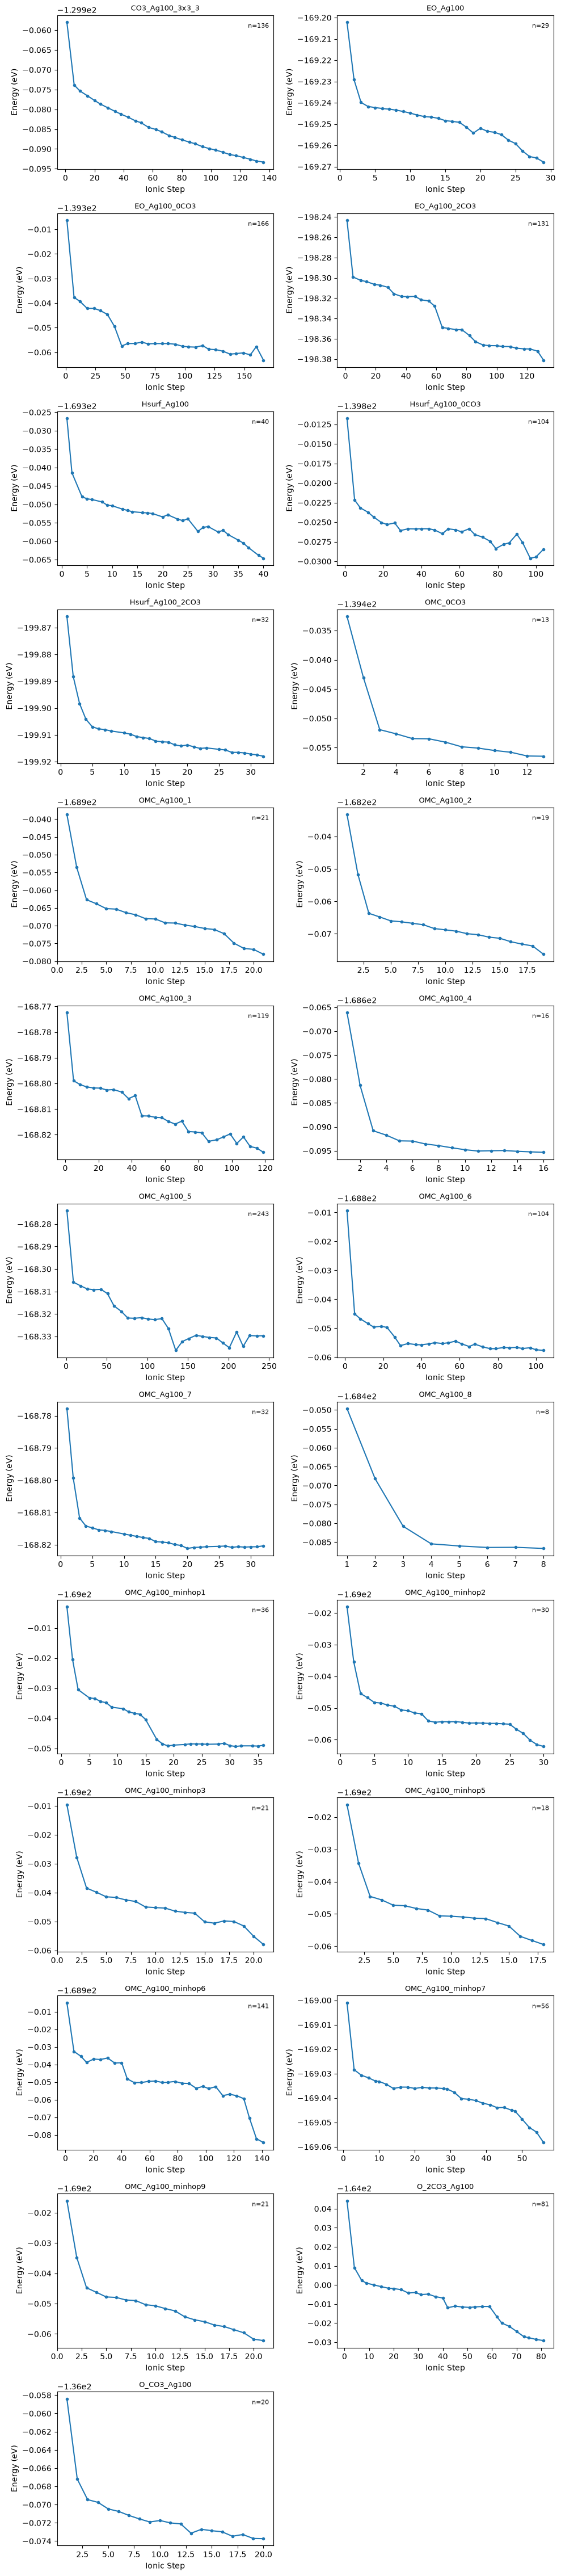

In [26]:
folderlist = foldernames[150:]
suffix_map = build_suffix_map(foldernames)

plot_energy_trajectories(folderlist, suffix_map=suffix_map)

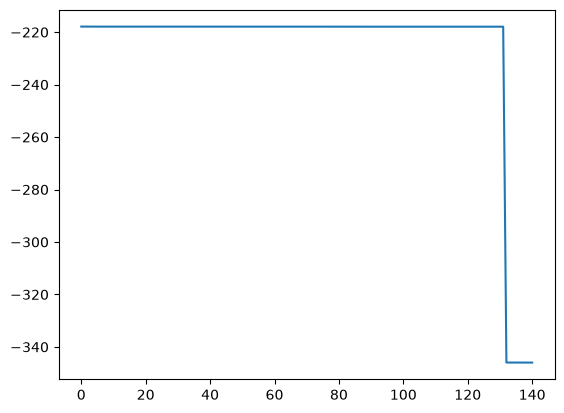

In [27]:
# graph individual runs (naive)

e_traj = get_energies("outcars/Ag100_OMC_OUTCAR")
e_traj.extend(get_energies("outcars/Ag100_OMC_OUTCAR-1"))

idxs = list(range(0, len(e_traj)))

plt.plot(idxs, e_traj)
plt.show()

_check edge cases again_

In [2]:
# check runs that were screened out

with open("cache/selected_foldernames.txt", "r", encoding="utf-8") as f:
    selectednames = [line.strip() for line in f]

with open("cache/screened_foldernames.txt", "r", encoding="utf-8") as f:
    screenednames = [line.strip() for line in f]

othernames = [k for k in selectednames if k not in screenednames]
print(len(othernames))

46


In [ ]:
# plot screened out runs (selected - screened names)

screened_suffix_map = build_suffix_map(othernames)
folderlist = othernames[0:10]

plot_energy_trajectories(folderlist, suffix_map=screened_suffix_map)